In [49]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./funlopt/funl_dynamics.jl")
include("./funlopt/funl_utils.jl")
include("./funlopt/funl_constraint.jl")
include("./trajopt/scaling.jl")

compute_scaling (generic function with 1 method)

In [50]:
# load nominal trajectory
using JLD2, FileIO
filename = "./data/nominal_traj_unicycle_case_long" 
@load filename my_dict
xnom = my_dict["x"]
unom = my_dict["u"]
tnom = my_dict["t"];
N = size(xnom,2) - 1
dtnom = zeros(N)
for i in 1:N
    dtnom[i] = tnom[i+1]-tnom[i]
end

In [51]:
function get_H_obs(rx,ry)
    return diagm([1/rx,1/ry])
end
c_list = []
H_list = []
radius = 0.5
push!(c_list, [1.8,0.3])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [2*2/3,3.5])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [4.2,0.7])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [3.8,3.5])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [10*2/3,0.5])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [6.5,4])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [4*2/3,1.7])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [8*2/3,2.3])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [0.5,2])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [8,2.3])
push!(H_list, get_H_obs(radius,radius))

vmax = 1.5
vmin = 0.0
wmax = 1.0
wmin = -1.0
list_const = Vector{FunnelConstraint}()
push!(list_const,InputConstraint([1;0],vmax))
push!(list_const,InputConstraint([-1;0],-vmin))
push!(list_const,InputConstraint([0; 1],wmax))
push!(list_const,InputConstraint([0; -1],-wmin))
for i = 1:length(c_list)
    push!(list_const,ObstacleAvoidance(H_list[i],c_list[i]))
end

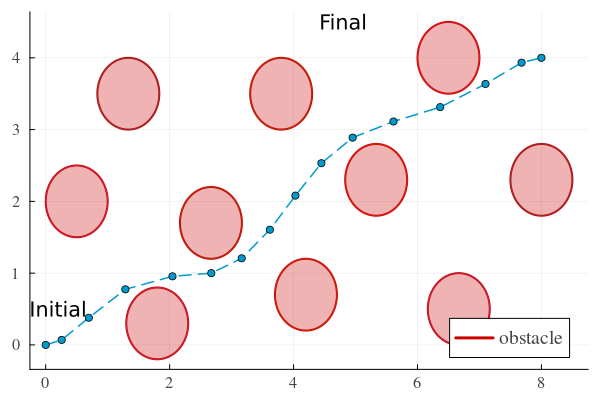

In [52]:
p2 = Plots.plot(; aspect_ratio=:auto)
plot!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
scatter!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linewidth=1.5,label=nothing)
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
annotate!(0.2, 0.5, text("Initial", :black, :center))
annotate!(4.8, 4.5, text("Final", :black, :center))
display(p2)

In [53]:
ix = 3
iu = 2
iw = 2
dynamics = Unicycle()

Unicycle(3, 2, 2, 3, 2, 10, 5, 2, 0, [0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; 1.0 0.0], 0.03, 0.05, #undef, #undef, #undef, #undef)

In [54]:
A = zeros(ix,ix,N+1)
B = zeros(ix,iu,N+1)
F = zeros(ix,iw,N+1)
for idx in 1:N+1
    A[:,:,idx],B[:,:,idx],F[:,:,idx] = diff_ABF(dynamics,xnom[:,idx],unom[:,idx])
end

In [55]:
Qmax = zeros(ix,ix,N+1)
for idx in 1:N+1
    Qmax[:,:,idx] .= diagm([2^2,2^2,deg2rad(20)^2])
end
Rmax = get_Rmax_unicycle(unom,N,vmax,vmin,wmax,wmin)
;

In [56]:
include("./funlopt/funl_utils.jl")

propagate_from_funnel_entry_uncertain_dynamics (generic function with 1 method)

In [57]:
gamma_est = Lipschitz_estimation_around_traj(N,100,xnom,unom,dynamics,Qmax,Rmax)
gamma = gamma_est[1:N];

In [77]:
gamma = gamma .* 0.0

15-element Vector{Matrix{Float64}}:
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]
 [0.0 0.0; 0.0 0.0]

# Estimation of $\beta$

In [78]:
using Interpolations

In [79]:
u_fit = [LinearInterpolation(tnom, unom[idx,:],extrapolation_bc=Flat()) for idx in 1:iu]
A_fit = [[LinearInterpolation(tnom, A[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
B_fit = [[LinearInterpolation(tnom, B[i,j,:], extrapolation_bc=Flat()) for j in 1:iu] for i in 1:ix ]
F_fit = [[LinearInterpolation(tnom, F[i,j,:], extrapolation_bc=Flat()) for j in 1:iw] for i in 1:ix ];


In [80]:
function model_wrapper!(f,x,p,t)
    um = p[1]
    up = p[2]
    dt = p[3]
    alpha = (dt - t) / dt
    beta = t / dt
    u1 = alpha*um + beta*up
    f .= forward(dynamics,x,u1)
end

model_wrapper! (generic function with 1 method)

In [81]:
N_sampling = 20
beta = []
beta_vec = []
for i = 1:N
    tspan = (0,tnom[i+1]-tnom[i])
    saveat = range(0, stop=tnom[i+1]-tnom[i], length=N_sampling)
    prob = ODEProblem(model_wrapper!,xnom[:,i],tspan,(unom[:,i],unom[:,i+1],tnom[i+1]-tnom[i]),saveat = saveat)
    sol = solve(prob, Tsit5(), reltol=1e-9, abstol=1e-9;verbose=false);
    @assert(isapprox(sol.u[end],xnom[:,i+1];atol=0.0001))
    delta = []
    delta_vec = zeros(N_sampling,6)
    for idx_sample = 1:N_sampling
        t_eval = sol.t[idx_sample] + tnom[i]
        x_eval = sol.u[idx_sample]
        u_eval = get_u_interp(t_eval,u_fit)
        A_eval,B_eval,F_eval = diff_ABF(dynamics,x_eval,u_eval)
        eA = get_ABF_interp(t_eval,A_fit,ix,ix) .- A_eval
        eB = get_ABF_interp(t_eval,B_fit,ix,iu) .- B_eval
        eF = get_ABF_interp(t_eval,F_fit,ix,iw) .- F_eval

        delta_ = [eA eB eF]
        push!(delta,opnorm(delta_,2))
        delta_vec[idx_sample,:] .= [abs(eA[1,3]), abs(eA[2,3]), abs(eB[1,1]), abs(eB[2,1]), abs(eF[1,1]), abs(eF[2,1])]
    end
    # push!(beta,maximum(delta))
    push!(beta,diagm(maximum(delta_vec,dims=1)[1,:]))
end

In [82]:
beta

15-element Vector{Any}:
 [0.06156916939016113 0.0 … 0.0 0.0; 0.0 0.024827876574522123 … 0.0 0.0; … ; 0.0 0.0 … 0.0018470750817048331 0.0; 0.0 0.0 … 0.0 0.0007448362972356619]
 [0.03336170565984803 0.0 … 0.0 0.0; 0.0 0.01738330756202988 … 0.0 0.0; … ; 0.0 0.0 … 0.0010008511697954421 0.0; 0.0 0.0 … 0.0 0.0005214992268608963]
 [0.07002951453516892 0.0 … 0.0 0.0; 0.0 0.03561949294068889 … 0.0 0.0; … ; 0.0 0.0 … 0.0021008854360550673 0.0; 0.0 0.0 … 0.0 0.0010685847882206598]
 [0.03522188975553514 0.0 … 0.0 0.0; 0.0 0.028008687359425855 … 0.0 0.0; … ; 0.0 0.0 … 0.0010566566926660526 0.0; 0.0 0.0 … 0.0 0.0008402606207827817]
 [0.06826103489035663 0.0 … 0.0 0.0; 0.0 0.007149311441140838 … 0.0 0.0; … ; 0.0 0.0 … 0.002047831046710699 0.0; 0.0 0.0 … 0.0 0.00021447934323422235]
 [0.0013722154689637112 0.0 … 0.0 0.0; 0.0 0.016514647939078198 … 0.0 0.0; … ; 0.0 0.0 … 4.116646406891224e-5 0.0; 0.0 0.0 … 0.0 0.0004954394381723459]
 [0.020424799965912288 0.0 … 0.0 0.0; 0.0 0.00953942307085942 … 0.0 0.0

In [83]:
C1 = [0 0 1;0 0 1;0 0 0;0 0 0;0 0 0;0 0 0]
D1 = [0 0;0 0;1 0;1 0;0 0;0 0]
G1 = [0 0;0 0;0 0;0 0;1 0;1 0]
E1 = [1 0 1 0 1 0;0 1 0 1 0 1;0 0 0 0 0 0]

dynamics.C = [C1;dynamics.Co]
dynamics.D = [D1;dynamics.Do]
dynamics.E = [E1 dynamics.Eo]
dynamics.G = [G1;dynamics.Go];

dynamics.ir = 6 + dynamics.iq
dynamics.idelta = 6
dynamics.ip = dynamics.idelta + dynamics.iphi

dynamics.ilam = dynamics.idelta + 1

7

In [84]:
dynamics.iphi

2

In [85]:
xmin = [0;0;0];
xmax = [1;1;pi];
umin = [0;0];
umax = [1;1];
scaler = Scaling(xmin, xmax, umin, umax, 1e3 * Matrix{Float64}(1.0I,dynamics.ilam,dynamics.ilam))

Scaling([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 3.141592653589793], [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 0.3183098861837907], [0.0, 0.0, 0.0], [1.0 0.0; 0.0 1.0], [1.0 0.0; 0.0 1.0], [0.0, 0.0], [1000.0 0.0 … 0.0 0.0; 0.0 1000.0 … 0.0 0.0; … ; 0.0 0.0 … 1000.0 0.0; 0.0 0.0 … 0.0 1000.0], 1.0)

In [86]:
include("./funlopt/funl_synthesis.jl")

run! (generic function with 1 method)

In [87]:
# lambda_w = 2.0
list_lambda_w = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,1.0]#,1.2,1.4,1.6,1.8,2.0]
list_solve_time = []
cost_lambda_w = []
list_fs = []
println("Line search for lambda_w from 0.01 to 2.0")
for lambda_w in list_lambda_w
        fs = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=1)
        cost,solve_time = run!(fs,
        gamma,
        beta,
        xnom,unom,tnom,Qmax,Rmax,"Mosek")
        println("lambda_w: ",lambda_w, " cost: ",abs(cost) < 1e-6 ? "diverged" : cost)
        push!(cost_lambda_w,cost)
        push!(list_fs,fs)
        push!(list_solve_time,solve_time)
end
idx_lambda_w = 1:length(list_lambda_w)
idx_converged = abs.(cost_lambda_w) .>= 1e-6
cost_lambda_w_converged = cost_lambda_w[idx_converged]
idx_fs = argmin(cost_lambda_w_converged)
idx_min = idx_lambda_w[idx_converged][idx_fs]

lambda_w = list_lambda_w[idx_min]
cost = cost_lambda_w[idx_min]
fs = list_fs[idx_min]
solve_time = list_solve_time[idx_min]

println(lambda_w," is picked. The corresponding cost is ",cost,". The solve time is ",solve_time,".")

Line search for lambda_w from 0.01 to 2.0
lambda_w: 0.01 cost: diverged
lambda_w: 0.1 cost: -0.9620302067330347
lambda_w: 0.2 cost: -0.9030482714428835
lambda_w: 0.3 cost: -0.8203692418374798
lambda_w: 0.4 cost: -0.7415366212937815
lambda_w: 0.5 cost: -0.67025795079816
lambda_w: 0.6 cost: -0.6063857003398658
lambda_w: 0.7 cost: -0.5489564806435676
lambda_w: 0.8 cost: -0.4957255426949299
lambda_w: 1.0 cost: -0.39521282223298276
0.1 is picked. The corresponding cost is -0.9620302067330347. The solve time is 0.9684150218963623.


In [88]:
fs2 = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=2)
cost,solve_time = run!(fs2,
gamma,
beta,
xnom,unom,tnom,Qmax,Rmax,"Mosek")
println("lambda_w: ",lambda_w, " cost: ",cost," solve time ",solve_time)

lambda_w: 0.1 cost: -0.9633762082851708 solve time 3.4245009422302246


In [89]:
Qnom_,Ynom_,lamnom_ = fs.solution.Q,fs.solution.Y,fs.solution.lam
Qnom,Ynom,lamnom = fs2.solution.Q,fs2.solution.Y,fs2.solution.lam

([0.5109784847631754 0.285291399490654 -0.0040111211589761; 0.285291399490654 0.3413971178904151 -0.14724525308962486; -0.0040111211589761 -0.14724525308962486 0.11584831598837178;;; 0.43056095609309813 0.27128785342831707 -0.01940720834253055; 0.27128785342831707 0.35105965700413966 -0.149601825410382; -0.01940720834253055 -0.149601825410382 0.115449428482697;;; 0.21575066450147648 0.11682818302007418 -0.013231339487377954; 0.11682818302007418 0.1479976006223259 -0.09375694284107705; -0.013231339487377954 -0.09375694284107705 0.09245022597153645;;; … ;;; 0.006306860842153389 -0.001446154469338693 0.009080106554005948; -0.001446154469338693 0.001680613955758353 -0.0033601361681910606; 0.009080106554005948 -0.0033601361681910606 0.016451837797183216;;; 0.0016438959914478481 -0.0017075809597824581 0.002681543881760581; -0.0017075809597824581 0.0020649217773944044 -0.003979441121091192; 0.002681543881760581 -0.003979441121091192 0.011821306483453298;;; 0.0002276964428231015 -0.00073160981

In [90]:
# Set default plot settings for academic paper
default(fontfamily="Times",  # Use Times New Roman font
        titlefont=14,        # Title font size
        guidefont=12,        # Label (guide) font size
        tickfont=10,         # Tick font size
        legendfont=12,       # Legend font size
        grid=true)          # Remove grid lines for a cleaner look


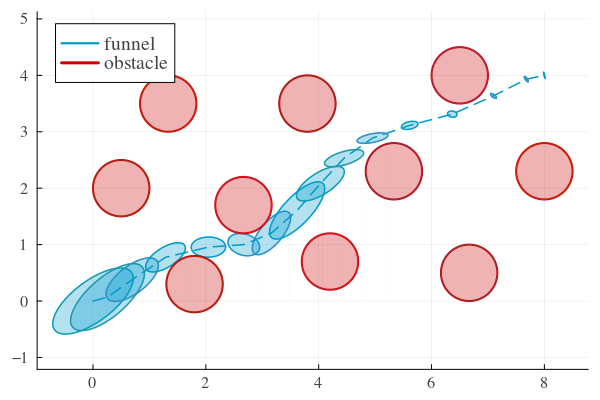

In [91]:
p2 = Plots.plot(; aspect_ratio=:auto)
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom_[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=true)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
display(p2)

In [92]:
input_proj_funl_node,Rnom = project_onto_input(Qnom,Ynom)

(Any[Any[0.1306252546314214, 0.6751057365163837, 0.5625045904208152, 0.3017736380578102, 0.3402260299486072, 0.5815133439350518, 0.6198470473213156, 0.47234952888741755, 0.5325651053423056, 0.5721500747737841, 0.47911392228364946, 0.34421462827637317, 0.27797102411254315, 0.29548983351409386, 0.7327906618659054, 0.22512866931499845], Any[0.4130461333245297, 0.25234947893860393, 0.9672356287612958, 0.2759408894370976, 0.6590902691666859, 0.32373520886807683, 0.47841937303917553, 0.7239458393978063, 0.8874379400451028, 0.654077315024248, 0.45979688953694275, 0.8717945518134936, 0.6587016492349949, 0.830558072061119, 0.43183579904174213, 0.49185906888452896]], [0.01706295714752368 8.53816852064472e-5; 8.538168520673463e-5 0.1706071082543452;;; 0.45576775547732895 -1.1048125735652125e-5; -1.1048125735497536e-5 0.06368025952058491;;; 0.31641141424448915 -2.0638618893249117e-5; -2.063861889332312e-5 0.9355447615452591;;; … ;;; 0.0873142417101869 0.0016780944366985935; 0.001678094436698576 0.

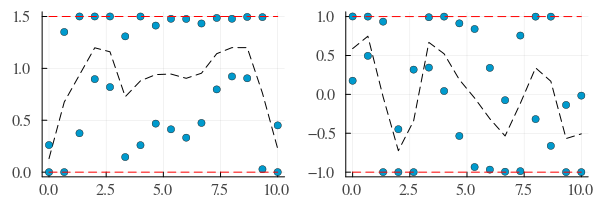

In [93]:
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[1,:]+input_proj_funl_node[1],color="deepskyblue3",label="")
scatter!(tnom,unom[1,:]-input_proj_funl_node[1],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[2,:]+input_proj_funl_node[2],color="deepskyblue3",label="")
scatter!(tnom,unom[2,:]-input_proj_funl_node[2],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
plot(p1,p2,layout=(1,2),size=(600,200))

# samples

In [94]:
Q_fit = [[LinearInterpolation(tnom, Qnom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
Y_fit = [[LinearInterpolation(tnom, Ynom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:iu ]
;

In [95]:
include("./funlopt/funl_utils.jl")

propagate_from_funnel_entry_uncertain_dynamics (generic function with 1 method)

In [96]:
num_sample = 100
xs_list = []
for i in 1:num_sample
    z = randn(ix)
    z = z / norm(z)
    push!(xs_list,xnom[:,1] + sqrt(Qnom[:,:,1]) * z)
end

In [97]:
xsam_fwd,tsam,xsam,usam,xnomprop = [],[],[],[],[]
i = 0
for xs in xs_list
    # println(i)
    i += 1
    xf_,ts_,xsam_,usam_,xnom_ = propagate_from_funnel_entry_uncertain_dynamics(xs,
        dynamics,
        xnom,unom,tnom,
        Qnom,Ynom)
    push!(xsam_fwd,xf_)
    push!(tsam,ts_)
    push!(xsam,xsam_)
    push!(usam,usam_)
    push!(xnomprop,xnom_)
end

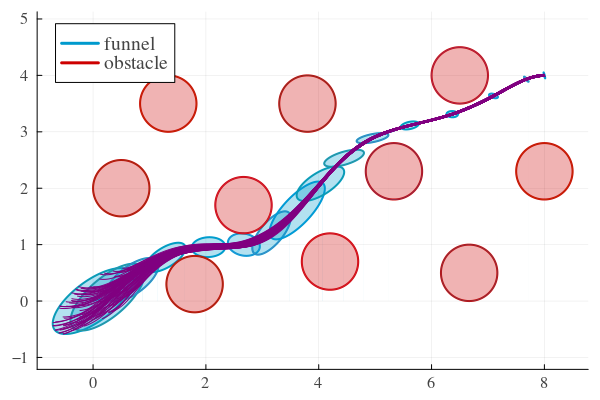

In [98]:
p2 = Plots.plot(; aspect_ratio=:auto)
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",label=label)
end
# plot_ellipse(p2,fs.solution.Qi,xnom[:,1],"green3",label="initial and final")
# plot_ellipse(p2,fs.solution.Qf,xnom[:,end],"green3")
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
for x_ in xsam
    plot!(x_[1,:],x_[2,:],color="purple",label=nothing)
end
display(p2)

In [99]:
# Lyapunov function
Lypsam = []
idx = 1
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    xprop_ = xnomprop[idx]
    Lyp = []
    for iode in 1:length(tsam_)
        t_ = tsam_[iode]
        x_ = xsam_[:,iode]
        xnom_ = xprop_[:,iode]
        Q_ = get_ABF_interp(t_,Q_fit,ix,ix)
        val = (x_ - xnom_)' * inv(Q_) * (x_ - xnom_)
        push!(Lyp,val)
    end
    push!(Lypsam,Lyp)
end


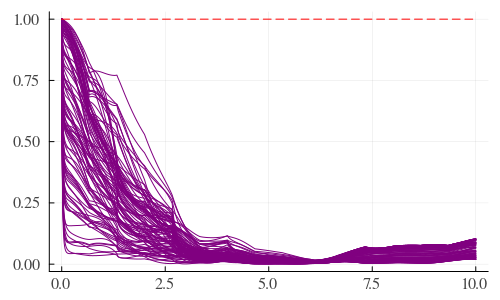

In [100]:
p3 = Plots.plot(; size=(500,300))
for idx = 1:length(tsam)
    plot!(tsam[idx],Lypsam[idx],c=:purple,label="")
end
plot!(tsam[1],tsam[1]*0 .+ 1.0,c=:red,linestyle=:dash,label="")
display(p3)

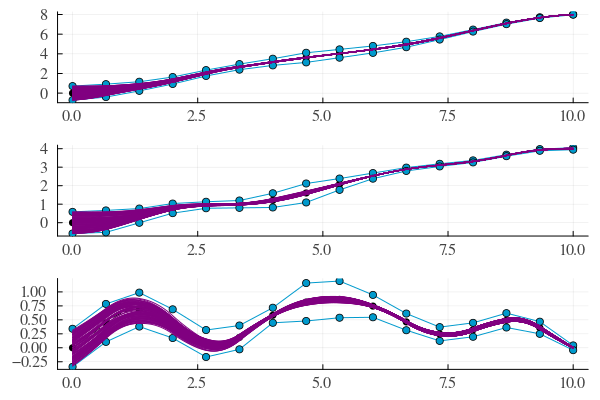

In [101]:
p1 = plot(tsam[1],xnomprop[1][1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[1,:] + sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[1,:] - sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[1,:],color="purple",label="")
end
p2 = plot(tsam[1],xnomprop[1][2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[2,:] + sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[2,:] - sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[2,:],color="purple",label="")
end
p3 = plot(tsam[1],xnomprop[1][3,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[3,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[3,:] + sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[3,:] - sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[3,:],color="purple",label="")
end
plot(p1,p2,p3,layout=(3,1),size=(600,400))

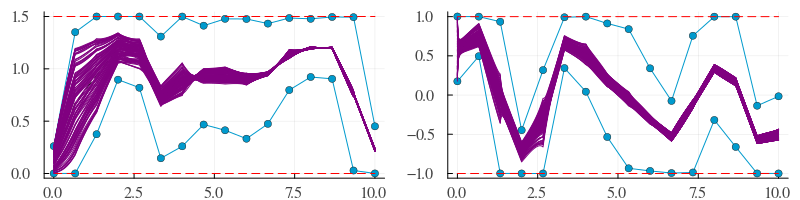

In [105]:
length_idx = length(tsam)
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[1,:]+input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[1,:]-input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[1,:],color="purple",label="")
end
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[2,:]+input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[2,:]-input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[2,:],color="purple",label="")
end
plot(p1,p2,layout=(1,2),size=(800,200))